# Industrial Anomaly Detection

This project detects abnormal industrial sensor observations and classifies them as **Normal (0)** or **Anomaly (1)**.

### Project Flow
**Problem Definition → Dataset Understanding → Data Cleaning → EDA → Preprocessing → Model Experiments → Evaluation → Final Model Selection → Deployment Preparation**

The compiled dataset is already prepared separately. This notebook starts directly from industrial_anomaly_data.csv.


## 1. Problem Definition

A manufacturing system continuously produces sensor readings such as pressure, temperature, current, voltage and vibration. Some observations represent normal operation while others represent abnormal operation.

The aim of this project is to build a supervised machine-learning classification model that can identify whether a new sensor observation is normal or anomalous.

### Prediction Output
- 0 → Normal operation
- 1 → Anomalous operation

### Main Goal
Build a high-performing and reliable anomaly classification model and use the final model later inside a Streamlit application.


## 2. Dataset Documentation

Dataset Link:

The dataset contains industrial process observations collected from sensor experiments. The available variables include vibration, current, pressure, temperature, thermocouple, voltage and flow measurements.

The final compiled file contains:
- 37,459 observations
- 8 sensor variables
- 1 datetime variable
- 1 anomaly target
- 1 changepoint indicator

The anomaly column is the prediction target. The changepoint column is not used as a model feature because it is an event/transition indicator and could give the model information that would not be available as a normal sensor input.


In [1]:
# Import the main Python libraries used in the project
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Read the compiled industrial anomaly dataset
df = pd.read_csv("industrial_anomaly_data.csv")


In [3]:
# Display the first few rows of the dataset
df.head()


,datetime,Accelerometer1RMS,Accelerometer2RMS,Current,Pressure,Temperature,Thermocouple,Voltage,Volume Flow RateRMS,anomaly,changepoint
0,2020-02-08 19:16:28,0.250072,0.293697,2.413220,0.382638,86.3671,28.7819,227.064,126.309,0.0,0.0
1,2020-02-08 19:16:29,0.243472,0.287044,3.054040,0.054711,86.0273,28.7853,243.736,126.000,0.0,0.0
2,2020-02-08 19:16:30,0.245552,0.281229,2.731000,0.054711,86.5074,28.7803,229.699,128.084,0.0,0.0
3,2020-02-08 19:16:31,0.247134,0.285976,0.938496,0.054711,86.4452,28.7803,208.689,126.931,0.0,0.0
4,2020-02-08 19:16:32,0.248327,0.291861,2.512480,-0.601143,86.3502,28.7842,233.663,126.000,0.0,0.0


In [4]:
# Check the number of rows and columns in the dataset
print("Rows:", df.shape[0], "Columns:", df.shape[1])


Rows: 37459 Columns: 11


In [5]:
# Check the column names and data types
print(df.dtypes)

datetime                   str
Accelerometer1RMS      float64
Accelerometer2RMS      float64
Current                float64
Pressure               float64
Temperature            float64
Thermocouple           float64
Voltage                float64
Volume Flow RateRMS    float64
anomaly                float64
changepoint            float64
dtype: object


In [6]:
# Check basic statistical information for the numeric columns
df.describe()

,Accelerometer1RMS,Accelerometer2RMS,Current,Pressure,Temperature,Thermocouple,Voltage,Volume Flow RateRMS,anomaly,changepoint
count,37459.000000,37459.000000,37459.000000,37459.000000,37459.000000,37459.000000,37459.000000,37459.000000,37459.000000,37459.000000
mean,0.109360,0.137253,1.649783,0.072395,76.815670,26.114163,229.626789,62.750736,0.353480,0.003470
std,0.133271,0.150142,6.381880,0.260662,8.843189,2.619162,12.691540,42.976640,0.478056,0.058809
min,0.000000,0.000000,0.355411,-1.257000,65.089000,22.020900,0.580776,0.000000,0.000000,0.000000
25%,0.027299,0.040121,0.890508,0.054711,69.057050,24.515100,223.750000,32.000000,0.000000,0.000000
50%,0.027882,0.041443,1.225850,0.054711,71.261700,25.017600,230.204000,32.031200,0.000000,0.000000
75%,0.216980,0.264674,2.059815,0.382638,86.356400,29.250100,236.123500,125.679000,1.000000,0.000000
max,0.722747,0.800498,243.829000,1.694350,95.011400,33.415100,255.324000,133.688000,1.000000,1.000000


In [7]:
# Check missing values in every column
print(df.isnull().sum())

datetime               0
Accelerometer1RMS      0
Accelerometer2RMS      0
Current                0
Pressure               0
Temperature            0
Thermocouple           0
Voltage                0
Volume Flow RateRMS    0
anomaly                0
changepoint            0
dtype: int64


In [8]:
# Check duplicated rows in the dataset
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 190


In [9]:
# Check the unique values available in the target and changepoint columns
print("Anomaly values:", df["anomaly"].unique()); print("Changepoint values:", df["changepoint"].unique())

Anomaly values: [0. 1.]
Changepoint values: [0. 1.]


In [10]:
# Show the number and percentage of normal and anomalous observations
print(df["anomaly"].value_counts()); print((df["anomaly"].value_counts(normalize=True)*100).round(2))

anomaly
0.0    24218
1.0    13241
Name: count, dtype: int64
anomaly
0.0    64.65
1.0    35.35
Name: proportion, dtype: float64


## 3. Initial Data Quality Findings

The dataset is checked for missing values, duplicates, incorrect data types and unusual target values.

The target contains two classes, normal and anomaly. The classes are not perfectly balanced, so accuracy alone will not be enough for evaluation; precision, recall and F1-score will also be reported.


In [11]:
# Convert the datetime column into a proper datetime format
df["datetime"] = pd.to_datetime(df["datetime"])

In [12]:
# Create a simple working copy after converting the datetime column
data = df.copy()

In [13]:
# Remove exact duplicate observations if any are present
data = data.drop_duplicates().reset_index(drop=True)

In [14]:
# Show the cleaned dataset size after duplicate removal
print("Cleaned dataset shape:", data.shape)

Cleaned dataset shape: (37269, 11)


## 4. Exploratory Data Analysis

The EDA is used to understand:
- target class distribution
- sensor distributions
- possible outliers
- relationships between variables
- correlation between sensor measurements
- how sensor values differ between normal and anomalous observations


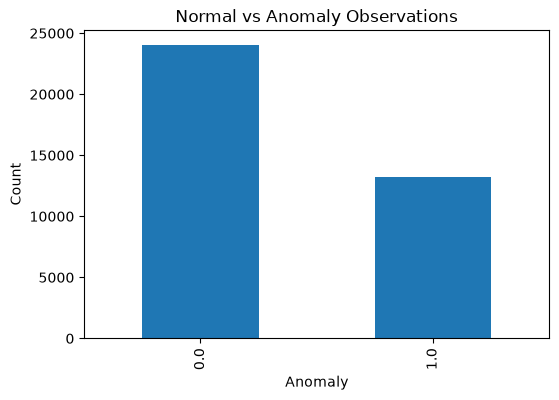

In [15]:
# Plot the distribution of normal and anomalous observations
plt.figure(figsize=(6,4)); data["anomaly"].value_counts().sort_index().plot(kind="bar"); 
plt.title("Normal vs Anomaly Observations"); plt.xlabel("Anomaly"); plt.ylabel("Count"); plt.show()

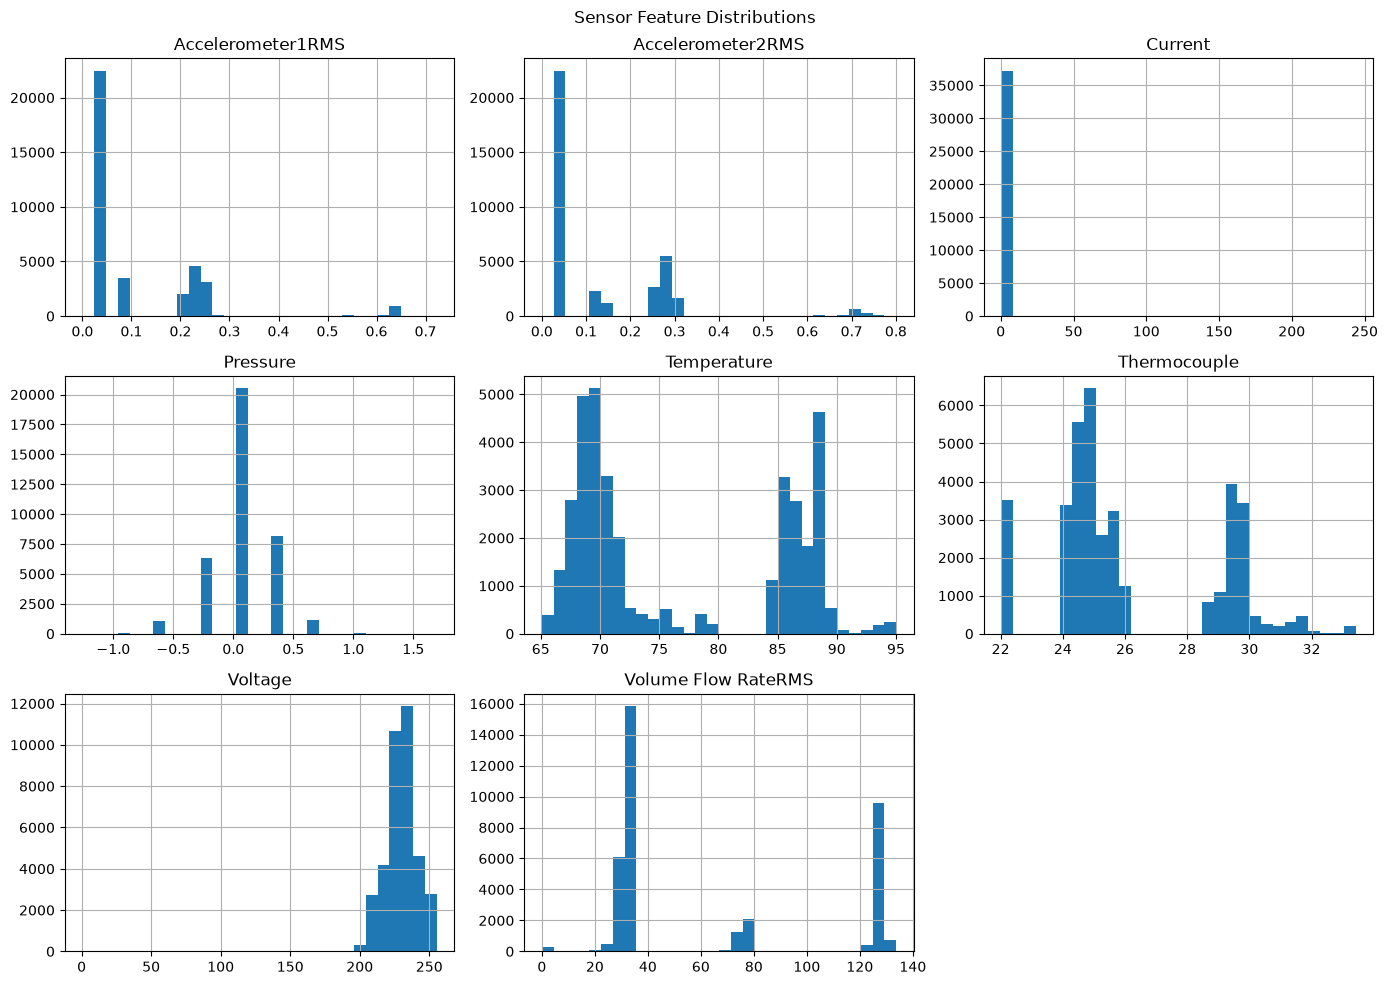

In [16]:
# Plot the distribution of the main sensor measurements
data.drop(columns=["datetime","anomaly","changepoint"]).hist(figsize=(14,10), bins=30); 
plt.suptitle("Sensor Feature Distributions"); plt.tight_layout(); plt.show()

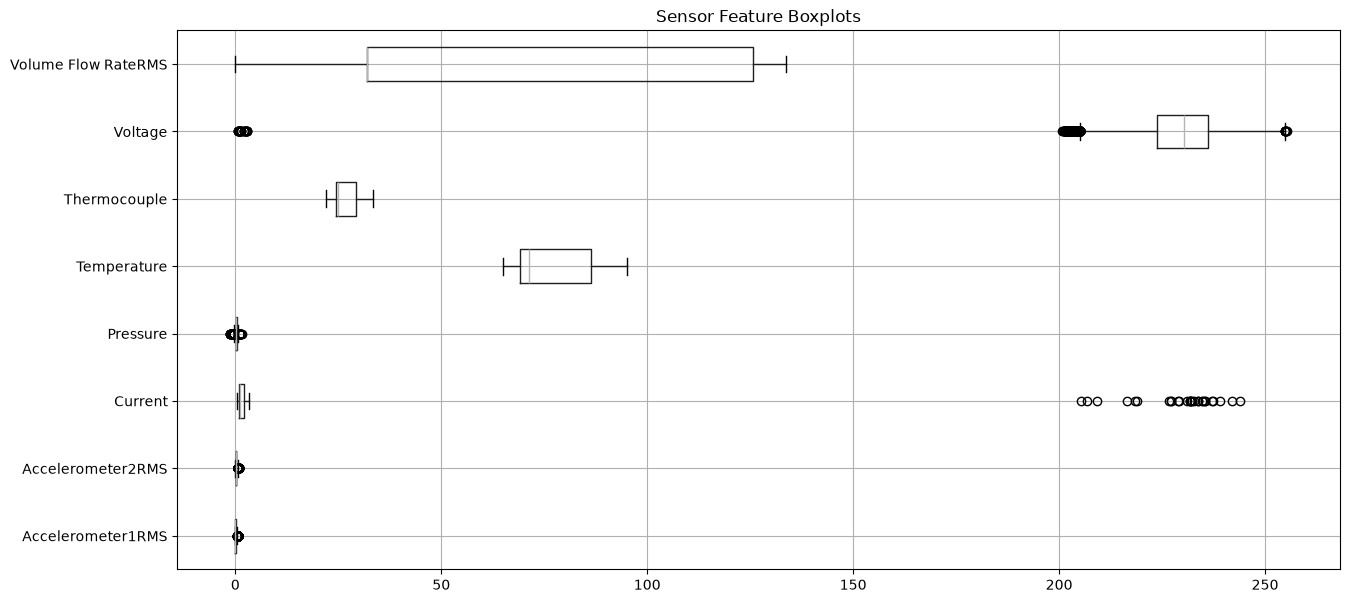

In [17]:
# Plot boxplots for the sensor variables to inspect possible outliers
plt.figure(figsize=(15,7)); data.drop(columns=["datetime","anomaly","changepoint"]).boxplot(vert=False); 
plt.title("Sensor Feature Boxplots"); plt.show()

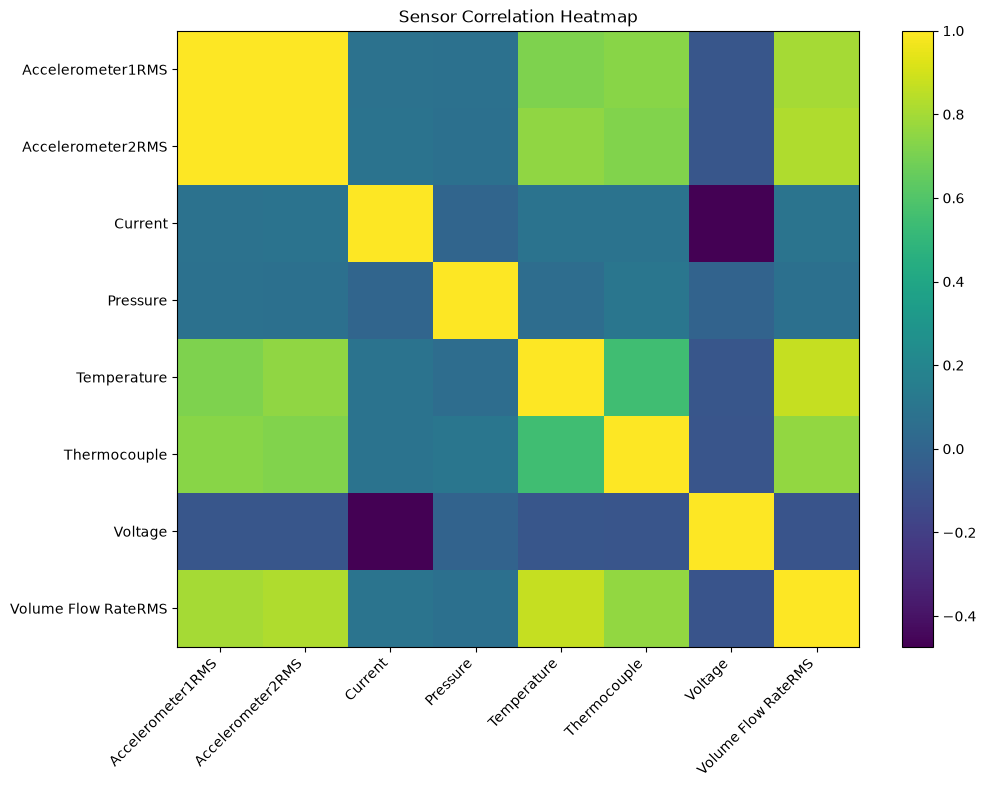

In [18]:
# Plot the correlation matrix for the sensor variables
plt.figure(figsize=(11,8)); plt.imshow(data.drop(columns=["datetime","anomaly","changepoint"]).corr(),aspect="auto"); 
plt.colorbar(); 
plt.xticks(range(len(data.drop(columns=["datetime","anomaly","changepoint"]).columns)),data.drop(columns=["datetime","anomaly","changepoint"]).columns,rotation=45,ha="right"); 
plt.yticks(range(len(data.drop(columns=["datetime","anomaly","changepoint"]).columns)),data.drop(columns=["datetime","anomaly","changepoint"]).columns); 
plt.title("Sensor Correlation Heatmap"); plt.show()

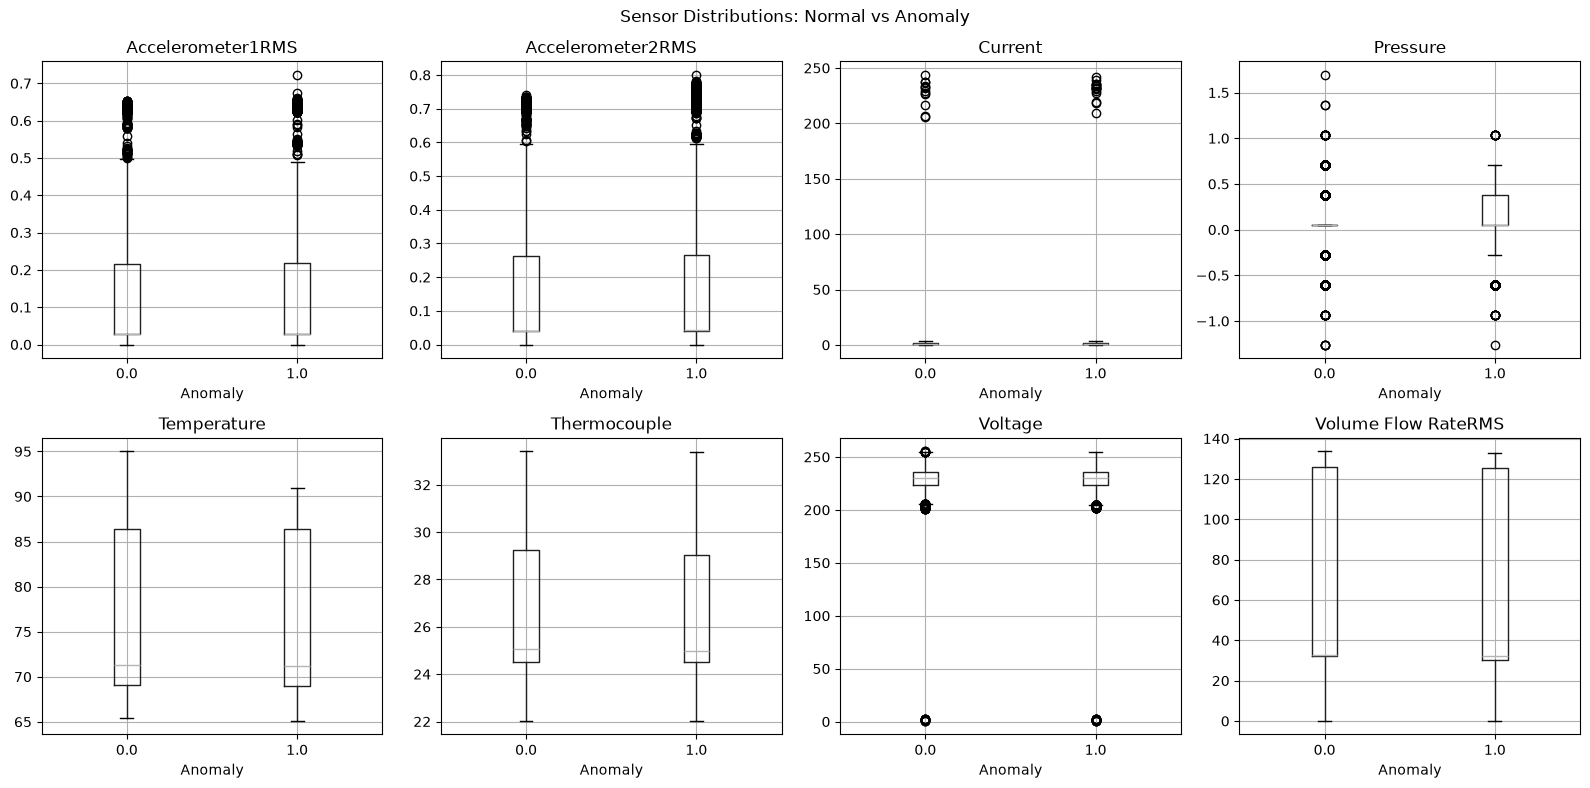

In [19]:
# Compare actual sensor distributions between normal and anomalous observations
sensor_cols = ["Accelerometer1RMS","Accelerometer2RMS","Current","Pressure","Temperature","Thermocouple","Voltage","Volume Flow RateRMS"]
fig, axes = plt.subplots(2,4,figsize=(16,8))
axes = axes.ravel()
for i,c in enumerate(sensor_cols[:len(axes)]):
    data.boxplot(column=c,by="anomaly",ax=axes[i])
    axes[i].set_title(c)
    axes[i].set_xlabel("Anomaly")
plt.suptitle("Sensor Distributions: Normal vs Anomaly")
plt.tight_layout()
plt.show()

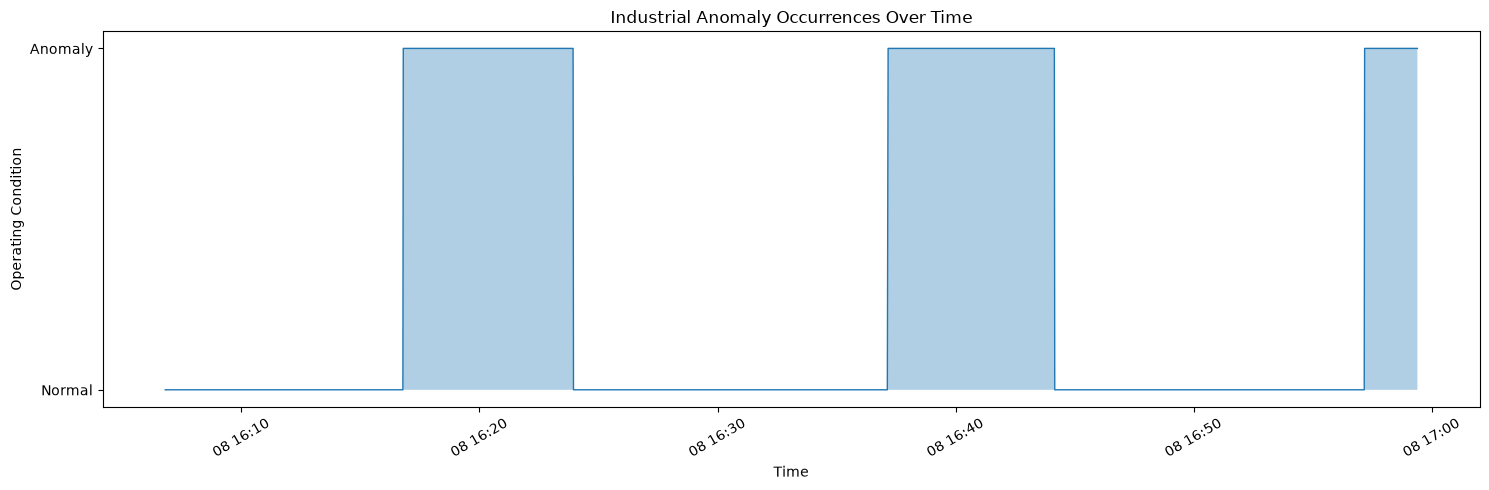

In [20]:
# Show normal and anomalous operating periods clearly over time
sample_data = data.sort_values("datetime").head(3000).copy()
sample_data["anomaly_change"] = sample_data["anomaly"].diff().fillna(0)

plt.figure(figsize=(15,5))
plt.plot(sample_data["datetime"], sample_data["anomaly"], linewidth=1)
plt.fill_between(sample_data["datetime"], 0, sample_data["anomaly"], alpha=0.35)
plt.yticks([0,1], ["Normal","Anomaly"])
plt.title("Industrial Anomaly Occurrences Over Time")
plt.xlabel("Time")
plt.ylabel("Operating Condition")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

In [21]:
# Show the average sensor values for normal and anomalous observations
print(data.groupby("anomaly")[sensor_cols].mean().round(3).T)

anomaly                  0.0      1.0
Accelerometer1RMS      0.106    0.113
Accelerometer2RMS      0.133    0.143
Current                1.574    1.777
Pressure               0.072    0.072
Temperature           76.778   76.760
Thermocouple          26.112   26.069
Voltage              229.714  229.513
Volume Flow RateRMS   63.133   62.566


## 5. EDA Findings

The EDA shows that the industrial sensor variables have different ranges and distributions, and the normal and anomalous observations can have different sensor patterns. The datetime column is kept for visual analysis only. It is not used as a model input so that the Streamlit application can make stable predictions from sensor readings alone.


In [22]:
# Keep datetime only for analysis and do not create time features for the classifier
print("Datetime is used for EDA only and is not included as a model feature.")


Datetime is used for EDA only and is not included as a model feature.


In [23]:
# Remove datetime and changepoint because they are not direct sensor inputs for the classifier
model_data = data.drop(columns=["datetime","changepoint"])


In [24]:
# Separate the eight sensor features from the anomaly target
X = model_data.drop(columns=["anomaly"]); y = model_data["anomaly"].astype(int)


In [25]:
# Check the final model features and target distribution
print("Features:", X.columns.tolist()); print("Target distribution:"); print(y.value_counts())

Features: ['Accelerometer1RMS', 'Accelerometer2RMS', 'Current', 'Pressure', 'Temperature', 'Thermocouple', 'Voltage', 'Volume Flow RateRMS']
Target distribution:
anomaly
0    24028
1    13241
Name: count, dtype: int64


## 6. Train, Validation and Test Split

In [26]:
# Split the data into training and temporary sets using stratification
from sklearn.model_selection import train_test_split
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, random_state=42, stratify=y)

In [27]:
# Split the temporary data into validation and test sets
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=2/3, random_state=42, stratify=y_temp)

In [28]:
# Display the final sizes of the training, validation and test sets
print("Training:", X_train.shape); print("Validation:", X_val.shape); print("Test:", X_test.shape)

Training: (26088, 8)
Validation: (3727, 8)
Test: (7454, 8)


## 7. Model Development

The following meaningful experiments are compared:

1. Logistic Regression — simple linear baseline
2. Random Forest — non-linear ensemble model
3. Extra Trees — randomized tree ensemble
4. HistGradientBoosting — gradient boosting model for non-linear sensor patterns

Accuracy, precision, recall and F1-score are compared because anomaly detection should not rely on accuracy alone.


In [29]:
# Import the machine-learning models and evaluation metrics
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, HistGradientBoostingClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report, roc_auc_score, roc_curve

In [30]:
# Train a Logistic Regression baseline model with feature scaling
lr = Pipeline([("scaler",StandardScaler()),("model",LogisticRegression(max_iter=1000,random_state=42))]); lr.fit(X_train,y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('scaler', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](8,)","['Accelerometer1RMS','Accelerometer2RMS','Current',...,'Thermocouple', 'Voltage','Volume Flow RateRMS']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,8
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


In [31]:
# Train the Random Forest model
rf = RandomForestClassifier(n_estimators=250,random_state=42,n_jobs=-1,class_weight="balanced"); rf.fit(X_train,y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",250
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"class_weight class_weight: {""balanced"", ""balanced_subsample""}, dict or list of dicts, default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one. Formulti-output problems, a list of dicts can be provided in the sameorder as the columns of y.Note that for multioutput (including multilabel) weights should bedefined for each class of every column in its own dict. For example,for four-class multilabel classification weights should be[{0: 1, 1: 1}, {0: 1, 1: 5}, {0: 1, 1: 1}, {0: 1, 1: 1}] instead of[{1:1}, {2:5}, {3:1}, {4:1}].The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``The ""balanced_subsample"" mode is the same as ""balanced"" except thatweights are computed based on the bootstrap sample for every treegrown.For multi-output, the weights of each column of y will be multiplied.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified.",'balanced'
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_fe

In [32]:
# Train the Extra Trees model
et = ExtraTreesClassifier(n_estimators=250,random_state=42,n_jobs=-1,class_weight="balanced"); et.fit(X_train,y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",250
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls 3 sources of randomness:- the bootstrapping of the samples used when building trees (if ``bootstrap=True``)- the sampling of the features to consider when looking for the best split at each node (if ``max_features < n_features``)- the draw of the splits for each of the `max_features`See :term:`Glossary <random_state>` for details.",42
,"class_weight class_weight: {""balanced"", ""balanced_subsample""}, dict or list of dicts, default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one. Formulti-output problems, a list of dicts can be provided in the sameorder as the columns of y.Note that for multioutput (including multilabel) weights should bedefined for each class of every column in its own dict. For example,for four-class multilabel classification weights should be[{0: 1, 1: 1}, {0: 1, 1: 5}, {0: 1, 1: 1}, {0: 1, 1: 1}] instead of[{1:1}, {2:5}, {3:1}, {4:1}].The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``The ""balanced_subsample"" mode is the same as ""balanced"" except thatweights are computed based on the bootstrap sample for every treegrown.For multi-output, the weights of each column of y will be multiplied.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified.",'balanced'
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when l

In [33]:
# Train the HistGradientBoosting model
hgb = HistGradientBoostingClassifier(max_iter=400,learning_rate=0.08,max_leaf_nodes=31,l2_regularization=0.1,random_state=42); 
hgb.fit(X_train,y_train)

,"learning_rate learning_rate: float, default=0.1The learning rate, also known as *shrinkage*. This is used as amultiplicative factor for the leaves values. Use ``1`` for noshrinkage.",0.08
,"max_iter max_iter: int, default=100The maximum number of iterations of the boosting process, i.e. themaximum number of trees for binary classification. For multiclassclassification, `n_classes` trees per iteration are built.",400
,"l2_regularization l2_regularization: float, default=0The L2 regularization parameter penalizing leaves with small hessians.Use ``0`` for no regularization (default).",0.1
,"random_state random_state: int, RandomState instance or None, default=NonePseudo-random number generator to control the subsampling in thebinning process, and the train/validation data split if early stoppingis enabled.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"loss loss: {'log_loss'}, default='log_loss'The loss function to use in the boosting process.For binary classification problems, 'log_loss' is also known as logistic loss,binomial deviance or binary crossentropy. Internally, the model fits one treeper boosting iteration and uses the logistic sigmoid function (expit) asinverse link function to compute the predicted positive class probability.For multiclass classification problems, 'log_loss' is also known as multinomialdeviance or categorical crossentropy. Internally, the model fits one tree perboosting iteration and per class and uses the softmax function as inverse linkfunction to compute the predicted probabilities of the classes.",'log_loss'
,"max_leaf_nodes max_leaf_nodes: int or None, default=31The maximum number of leaves for each tree. Must be strictly greaterthan 1. If None, there is no maximum limit.",31
,"max_depth max_depth: int or None, default=NoneThe maximum depth of each tree. The depth of a tree is the number ofedges to go from the root to the deepest leaf.Depth isn't constrained by default.",None
,"min_samples_leaf min_samples_leaf: int, default=20The minimum number of samples per leaf. For small datasets with lessthan a few hundred samples, it is recommended to lower this valuesince only very shallow trees would be built.",20
,"max_features max_features: float, default=1.0Proportion of randomly chosen features in each and every node split.This is a form of regularization, smaller values make the trees weakerlearners and might prevent overfitting.If interaction constraints from `interaction_cst` are present, only allowedfeatures are taken into account for the subsampling... versionadded:: 1.4",1.0
,"max_bins max_bins: int, default=255The maximum number of bins to use for non-missing values. Beforetraining, each feature of the input array `X` is binned intointeger-valued bins, which allows for a much faster training stage.Features with a small number of unique values may use less than``max_bins`` bins. In addition to the ``max_bins`` bins, one more binis always reserved for missing values. Must be no larger than 255.",255
,"categorical_features categorical_features: array-like of {bool, int, str} of shape (n_features) or shape (n_categorical_features,), default='from_dtype'Indicates the categorical features.- None : no feature will be considered categorical.- boolean array-like : boolean mask indicating categorical features.- integer array-like : integer indices indicating categorical features.- str array-like: names of categorical features (assuming the training data has feature names).- `""from_dtype""`: dataframe columns with dtype ""Categorical"" and ""Enum"" are considered to be categorical features. The input must be a dataframe that is supported by narwhals (or supports it): :func:`narwhals.from_native` must work. This is the case, for instance, for pandas and polars DataFrames.For each categorical feature, there must be at most `max_bins` uniquecategories. Negative values for categorical features encoded as numericdtypes are treated as missing va

In [34]:
# Compare the four models on the validation dataset
models = {"Logistic Regression":lr,"Random Forest":rf,"Extra Trees":et,"HistGradientBoosting":hgb}; results=[]; 
for name,model in models.items():
    pred=model.predict(X_val); 
    results.append([name,accuracy_score(y_val,pred),precision_score(y_val,pred),recall_score(y_val,pred),f1_score(y_val,pred)])
results_df=pd.DataFrame(results,columns=["Model","Accuracy","Precision","Recall","F1 Score"]).sort_values("F1 Score",ascending=False); 
results_df

,Model,Accuracy,Precision,Recall,F1 Score
3,HistGradientBoosting,0.928361,0.932134,0.861027,0.895171
1,Random Forest,0.924604,0.917534,0.865559,0.890789
2,Extra Trees,0.915482,0.934539,0.819486,0.873239
0,Logistic Regression,0.645559,0.516484,0.035498,0.066431


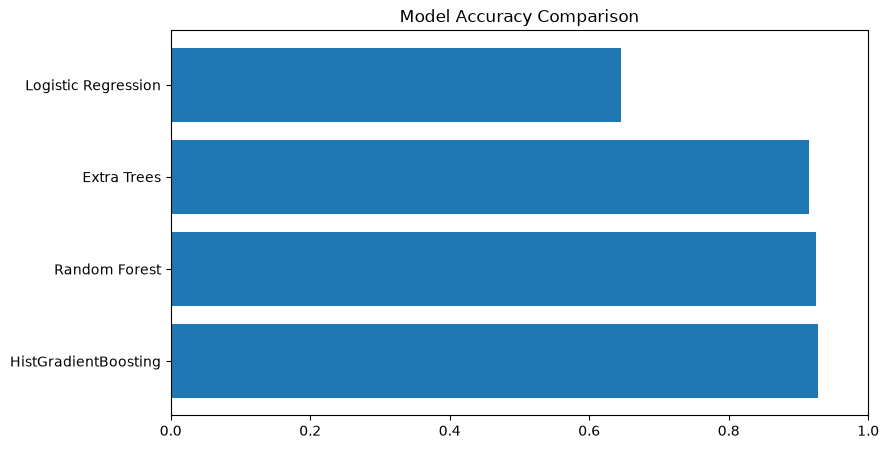

In [35]:
# Plot the validation accuracy of the tested models
plt.figure(figsize=(9,5)); 
plt.barh(results_df["Model"],results_df["Accuracy"]); 
plt.xlim(0,1); 
plt.title("Model Accuracy Comparison"); 
plt.show()

## 8. Model Selection

The validation results are used to select the final algorithm based on overall classification performance.

In [36]:
# Select the model with the highest validation F1-score from the experiment
best_model_name = results_df.iloc[0]["Model"]; final_model = models[best_model_name]
print("Selected model:",best_model_name)


Selected model: HistGradientBoosting


In [37]:
# Generate validation probabilities for checking a practical classification threshold
val_prob = final_model.predict_proba(X_val)[:,1]

In [38]:
# Search for a validation threshold that gives the highest validation accuracy
thresholds = np.arange(0.20,0.81,0.01); threshold_results = [[t,accuracy_score(y_val,(val_prob>=t).astype(int))] for t in thresholds]; 
threshold_df=pd.DataFrame(threshold_results,columns=["Threshold","Accuracy"]); 
best_threshold=float(threshold_df.loc[threshold_df["Accuracy"].idxmax(),"Threshold"]); 
print("Best validation threshold:",best_threshold); 
print("Best validation accuracy:",threshold_df["Accuracy"].max())

Best validation threshold: 0.4100000000000002
Best validation accuracy: 0.9297021733297558


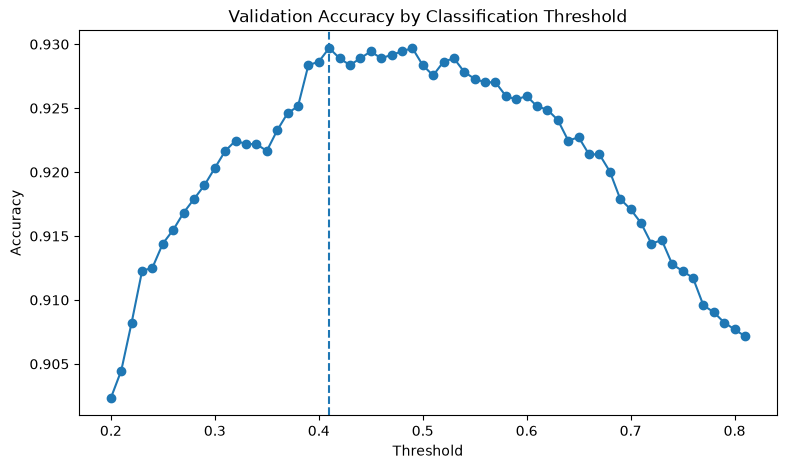

In [39]:
# Plot validation accuracy for different probability thresholds
plt.figure(figsize=(9,5)); 
plt.plot(threshold_df["Threshold"],threshold_df["Accuracy"],marker="o"); 
plt.axvline(best_threshold,linestyle="--"); 
plt.title("Validation Accuracy by Classification Threshold"); 
plt.xlabel("Threshold"); 
plt.ylabel("Accuracy"); 
plt.show()

## 9. Final Model Evaluation

The final evaluation includes:
- Accuracy
- Precision
- Recall
- F1-score
- ROC-AUC
- Confusion matrix
- Classification report


In [40]:
# Combine the training and validation data for final model training
X_train_final = pd.concat([X_train,X_val]); y_train_final = pd.concat([y_train,y_val])

In [41]:
# Retrain the selected model on the full development data
if best_model_name == "Logistic Regression":
    final_model = Pipeline([("scaler",StandardScaler()),("model",LogisticRegression(max_iter=1000,random_state=42))])
elif best_model_name == "Random Forest":
    final_model = RandomForestClassifier(n_estimators=250,random_state=42,n_jobs=-1,class_weight="balanced")
elif best_model_name == "Extra Trees":
    final_model = ExtraTreesClassifier(n_estimators=250,random_state=42,n_jobs=-1,class_weight="balanced")
else:
    final_model = HistGradientBoostingClassifier(max_iter=400,learning_rate=0.08,max_leaf_nodes=31,l2_regularization=0.1,random_state=42)
final_model.fit(X_train_final,y_train_final)


,"learning_rate learning_rate: float, default=0.1The learning rate, also known as *shrinkage*. This is used as amultiplicative factor for the leaves values. Use ``1`` for noshrinkage.",0.08
,"max_iter max_iter: int, default=100The maximum number of iterations of the boosting process, i.e. themaximum number of trees for binary classification. For multiclassclassification, `n_classes` trees per iteration are built.",400
,"l2_regularization l2_regularization: float, default=0The L2 regularization parameter penalizing leaves with small hessians.Use ``0`` for no regularization (default).",0.1
,"random_state random_state: int, RandomState instance or None, default=NonePseudo-random number generator to control the subsampling in thebinning process, and the train/validation data split if early stoppingis enabled.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"loss loss: {'log_loss'}, default='log_loss'The loss function to use in the boosting process.For binary classification problems, 'log_loss' is also known as logistic loss,binomial deviance or binary crossentropy. Internally, the model fits one treeper boosting iteration and uses the logistic sigmoid function (expit) asinverse link function to compute the predicted positive class probability.For multiclass classification problems, 'log_loss' is also known as multinomialdeviance or categorical crossentropy. Internally, the model fits one tree perboosting iteration and per class and uses the softmax function as inverse linkfunction to compute the predicted probabilities of the classes.",'log_loss'
,"max_leaf_nodes max_leaf_nodes: int or None, default=31The maximum number of leaves for each tree. Must be strictly greaterthan 1. If None, there is no maximum limit.",31
,"max_depth max_depth: int or None, default=NoneThe maximum depth of each tree. The depth of a tree is the number ofedges to go from the root to the deepest leaf.Depth isn't constrained by default.",None
,"min_samples_leaf min_samples_leaf: int, default=20The minimum number of samples per leaf. For small datasets with lessthan a few hundred samples, it is recommended to lower this valuesince only very shallow trees would be built.",20
,"max_features max_features: float, default=1.0Proportion of randomly chosen features in each and every node split.This is a form of regularization, smaller values make the trees weakerlearners and might prevent overfitting.If interaction constraints from `interaction_cst` are present, only allowedfeatures are taken into account for the subsampling... versionadded:: 1.4",1.0
,"max_bins max_bins: int, default=255The maximum number of bins to use for non-missing values. Beforetraining, each feature of the input array `X` is binned intointeger-valued bins, which allows for a much faster training stage.Features with a small number of unique values may use less than``max_bins`` bins. In addition to the ``max_bins`` bins, one more binis always reserved for missing values. Must be no larger than 255.",255
,"categorical_features categorical_features: array-like of {bool, int, str} of shape (n_features) or shape (n_categorical_features,), default='from_dtype'Indicates the categorical features.- None : no feature will be considered categorical.- boolean array-like : boolean mask indicating categorical features.- integer array-like : integer indices indicating categorical features.- str array-like: names of categorical features (assuming the training data has feature names).- `""from_dtype""`: dataframe columns with dtype ""Categorical"" and ""Enum"" are considered to be categorical features. The input must be a dataframe that is supported by narwhals (or supports it): :func:`narwhals.from_native` must work. This is the case, for instance, for pandas and polars DataFrames.For each categorical feature, there must be at most `max_bins` uniquecategories. Negative values for categorical features encoded as numericdtypes are treated as missing va

In [42]:
# Generate final test probabilities and predictions using the selected threshold
test_prob = final_model.predict_proba(X_test)[:,1]; test_pred = (test_prob>=best_threshold).astype(int)

In [43]:
# Calculate the final model performance metrics on the unseen test data
final_accuracy=accuracy_score(y_test,test_pred); final_precision=precision_score(y_test,test_pred); final_recall=recall_score(y_test,test_pred); final_f1=f1_score(y_test,test_pred); final_auc=roc_auc_score(y_test,test_prob); print("Final Model:",best_model_name); print("Accuracy:",round(final_accuracy,4)); print("Precision:",round(final_precision,4)); print("Recall:",round(final_recall,4)); print("F1 Score:",round(final_f1,4)); print("ROC-AUC:",round(final_auc,4))


Final Model: HistGradientBoosting
Accuracy: 0.9277
Precision: 0.9105
Recall: 0.8833
F1 Score: 0.8967
ROC-AUC: 0.979


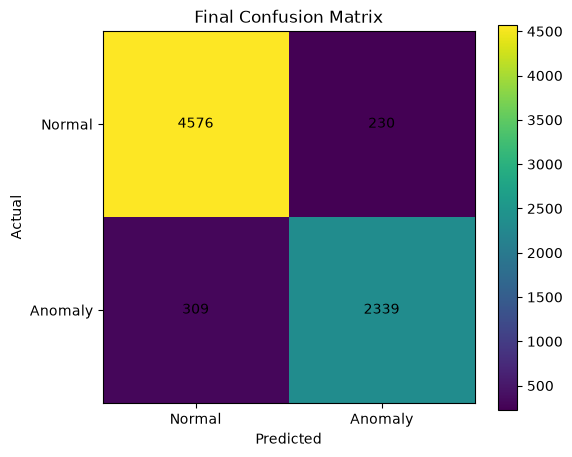

In [44]:
# Display the final confusion matrix for normal and anomaly predictions
cm=confusion_matrix(y_test,test_pred); 
plt.figure(figsize=(6,5)); plt.imshow(cm); 
plt.colorbar(); plt.xticks([0,1],["Normal","Anomaly"]); 
plt.yticks([0,1],["Normal","Anomaly"]); [plt.text(j,i,str(cm[i,j]),ha="center",va="center") for i in range(2) for j in range(2)]; 
plt.title("Final Confusion Matrix"); plt.xlabel("Predicted"); plt.ylabel("Actual"); plt.show()

In [45]:
# Display precision, recall and F1-score for both classes
print(classification_report(y_test,test_pred,target_names=["Normal","Anomaly"]))

              precision    recall  f1-score   support

      Normal       0.94      0.95      0.94      4806
     Anomaly       0.91      0.88      0.90      2648

    accuracy                           0.93      7454
   macro avg       0.92      0.92      0.92      7454
weighted avg       0.93      0.93      0.93      7454



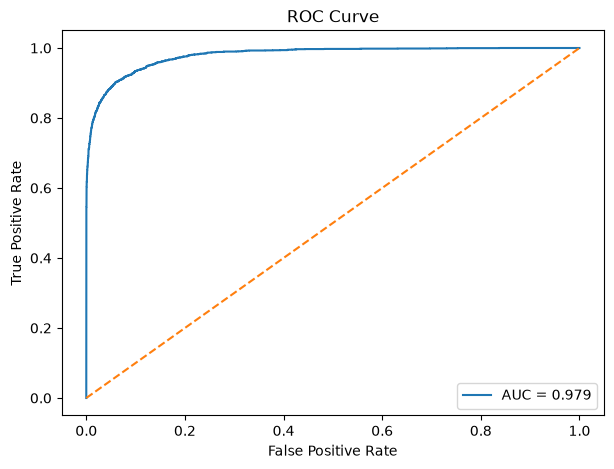

In [46]:
# Plot the ROC curve for the final anomaly classifier
fpr,tpr,_=roc_curve(y_test,test_prob); 
plt.figure(figsize=(7,5)); 
plt.plot(fpr,tpr,label=f"AUC = {final_auc:.3f}"); 
plt.plot([0,1],[0,1],"--"); 
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate"); plt.title("ROC Curve"); plt.legend(); plt.show()

In [47]:
# Calculate permutation importance for the final model features
from sklearn.inspection import permutation_importance
perm = permutation_importance(final_model,X_test,y_test,n_repeats=5,random_state=42,n_jobs=-1)
importance = pd.Series(perm.importances_mean,index=X.columns).sort_values(ascending=False); print(importance)

Volume Flow RateRMS    0.288463
Temperature            0.195063
Thermocouple           0.162758
Accelerometer1RMS      0.099168
Accelerometer2RMS      0.024014
Current                0.001288
Pressure              -0.000322
Voltage               -0.000510
dtype: float64


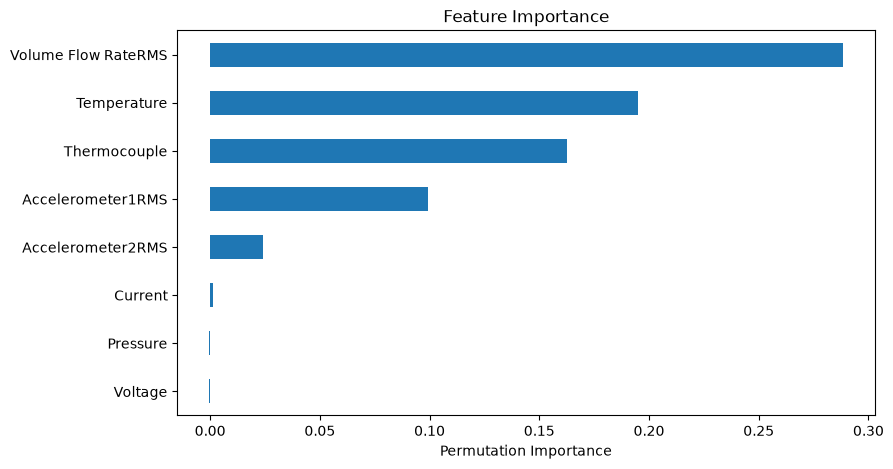

In [48]:
# Plot the most important sensor features
plt.figure(figsize=(9,5)); importance.sort_values().plot(kind="barh"); 
plt.title("Feature Importance"); plt.xlabel("Permutation Importance"); plt.show()


## 10. Error and Result Analysis

The confusion matrix shows the types of mistakes made by the model:

- **True Positive** → anomaly correctly detected
- **True Negative** → normal operation correctly detected
- **False Positive** → normal observation incorrectly flagged as anomaly
- **False Negative** → anomaly incorrectly classified as normal

False negatives are particularly important in industrial anomaly detection because an undetected abnormal condition can be more serious than an additional inspection caused by a false alarm.

The model should therefore be evaluated using recall and F1-score in addition to accuracy.


In [49]:
# Show the actual false positive and false negative counts
tn,fp,fn,tp=cm.ravel(); print("True Negatives:",tn); 
print("False Positives:",fp); 
print("False Negatives:",fn); print("True Positives:",tp)

True Negatives: 4576
False Positives: 230
False Negatives: 309
True Positives: 2339


## 11. Limitations

1. The dataset represents benchmark industrial experiments and may not cover every real manufacturing environment.
2. Sensor ranges and anomaly patterns can change between machines and production conditions.
3. The model is trained on the available labelled experiments, so unseen failure modes may not be detected reliably.
4. The classification threshold was selected using the validation data and should be reviewed when deployment conditions change.
5. A production system would require continuous monitoring, retraining and domain-specific safety validation.


In [50]:
# Show the exact sensor columns that the future Streamlit application must provide
print("Streamlit input columns:"); print(X.columns.tolist()); print("Classification threshold:",best_threshold); print("Selected model:",best_model_name)


Streamlit input columns:
['Accelerometer1RMS', 'Accelerometer2RMS', 'Current', 'Pressure', 'Temperature', 'Thermocouple', 'Voltage', 'Volume Flow RateRMS']
Classification threshold: 0.4100000000000002
Selected model: HistGradientBoosting


# Final Result

The project completes the required machine-learning workflow:

**Problem Definition → Dataset Documentation → Data Quality Checks → EDA → Preprocessing → Model Comparison → Model Selection → Threshold Selection → Final Evaluation → Error Analysis → Limitations → Streamlit Deployment Preparation**

The final deployment input contains only the eight industrial sensor readings, so the same sensor values will produce the same prediction each time.
